In [ ]:
from google.colab import drive
import os

# 1. Driveをマウント
drive.mount('/content/drive')

# 2. ログ保存用のフォルダを作成
LOG_DIR = "/content/drive/MyDrive/Research_Logs"
os.makedirs(LOG_DIR, exist_ok=True)

print(f"✅ ログ保存先: {LOG_DIR}")

Mounted at /content/drive
✅ ログ保存先: /content/drive/MyDrive/Research_Logs


In [ ]:
%pip install rank_bm25
from pathlib import Path
import sys
import torch
from datasets import load_dataset
from datetime import datetime

import huggingface_hub
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(hf_token)


# 以下自作モジュール
module_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/my_modules"
if module_path not in sys.path:
    sys.path.append(module_path)

from DynamicScalingLlamaAttention import DynamicScalingLlamaAttention
from ScalingController import ScalingController
from get_model_safe import get_model_safe, test_patched_model_sanity, remove_cache
from main_inference import main_inference
from run_eval import run_eval_exact_match
from analyze_log import ExperimentAnalyzer


if 'CACHED_MODEL' not in globals():
    CACHED_MODEL = None
    CACHED_TOKENIZER = None

# attention テストコード
# test_patched_model_sanity("meta-llama/Llama-2-7b-chat-hf")

# hotpot datasetのロード
# print("Loading dataset...")
# dataset = load_dataset("hotpot_qa", "distractor", split="validation")

In [ ]:
# kv_retrieval task
%pip install xopen

from xopen import xopen
import json
import gc
import torch
import torch.nn as nn
from tqdm import tqdm
import random

random.seed(0)

def calculate_nll(model, tokenizer, prompt, value, kv_positions):
    """model()によるprefillを行い、ppl, attention mapを返す"""
    full_text = prompt + " " + value
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    kv_token_positions = []
    for start_char, end_char in kv_positions:
        start_idx = inputs.char_to_token(start_char)
        end_idx = inputs.char_to_token(end_char-1)
        kv_token_positions.append((start_idx, end_idx))

    input_ids = inputs.input_ids

    target_ids = tokenizer(value, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
    target_len = target_ids.shape[1]

    with torch.no_grad():
        outputs = model(input_ids)

    logits = outputs.logits # [1, seq_len, vocab_size]
    target_logits = logits[0, -(target_len+1):-1, :]
    target_labels = input_ids[0, -target_len:]

    # 15～20層の最後のトークンに対するアテンションマップを取得
    target_layers_attentions = outputs.attentions[14:20] # [num_layers, batch_size, num_heads, seq_len, seq_len]
    last_token_attentions = torch.stack([layer[:,:,-1,:] for layer in target_layers_attentions]) # (target_layers, bsz, num_heads, 1, seq_len)

    # 負の対数尤度の平均
    loss_fct = nn.CrossEntropyLoss(reduction="mean")
    avg_nll = loss_fct(target_logits, target_labels)

    del outputs

    return {
        "avg_nll": avg_nll.item(),
        "target_len": target_len,
        "kv_token_positions": kv_token_positions,
    }, last_token_attentions

def format_kv_prompt(records, key)->str:
    """keyとrecordsからプロンプトの作成"""
    kv_dict = {r[0]: r[1] for r in records}
    context = json.dumps(kv_dict)

    header = "Extract the value corresponding to the specified key in the JSON object below.\n\nJSON data:\n"
    footer = f'\n\nKey: "{key}"\nCorresponding value:'

    prompt = header + "{"
    positions = []
    for i, record in enumerate(records):
      kv_str = json.dumps({record[0]: record[1]})[1:-1]

      start_idx = len(prompt)
      prompt += kv_str
      end_idx = len(prompt)

      positions.append((start_idx, end_idx))
      if i < len(records) -1:
        prompt += ", "
    prompt += "}"
    context_end_idx = len(prompt)
    prompt = prompt + footer

    return prompt, context_end_idx, positions

def shuffle_records(records, sample_num, target_key, target_value):
    """
    recordsから正解ペアを確保し、他のレコードと混ぜてから、
    指定されたsample_numの範囲内のランダムな位置に正解を挿入する。
    """
    gold_pair = [target_key, target_value]
    other_records = [r for r in records if r != gold_pair]
    random.shuffle(other_records)
    selected_others = other_records[:sample_num - 1]
    random_pos = random.randint(0, len(selected_others))

    selected_others.insert(random_pos, gold_pair)

    return selected_others


def get_records_at_position(records, sample_num, target_key, target_value, pos):
    gold_pair = [target_key, target_value]
    other_records = [r for r in records if r != gold_pair]
    # 他のレコードの順序は固定し、指定された数だけ抽出
    selected_others = other_records[:sample_num - 1]

    # 指定された位置に正解を挿入
    selected_others.insert(pos, gold_pair)
    return selected_others


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 13.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import itertools
import traceback
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def run_kv_retrieval(records, key, value, model, tokenizer, IS_SCALE=True, SCALE_NUM=1):
    # 1. プロンプトの作成
    prompt, context_end_idx, kv_char_positions = format_kv_prompt(records, key)
    full_text = prompt + " " + value

    # 2. トークナイズ
    inputs = tokenizer(full_text, return_tensors="pt", return_offsets_mapping=True).to(model.device)
    input_ids = inputs.input_ids
    target_ids = tokenizer(value, add_special_tokens=False).input_ids
    target_len = len(target_ids)

    # 3. スケールマップの作成
    char_start = prompt.find(key, 0, context_end_idx)
    char_end = char_start + len(key)
    seq_len = input_ids.shape[1]
    scale_map = torch.full((1, seq_len), 1.0, device=model.device, dtype=torch.float16)

    # gold keyのトークンの次元の操作
    offsets = inputs.offset_mapping[0]
    found_gold = False
    if char_start != -1:
        for t_i, (off_start, off_end) in enumerate(offsets):
            if off_start == off_end: continue
            if off_end > char_start and off_start < char_end:
                scale_map[0, t_i] += 20 # 実験用のスケーリング
                found_gold = True
                break
    if not found_gold:
        print("⚠️ Gold key not found")
        return None
    model.config.current_scale_map = scale_map

    # --- 4. Hook（フック）の設定：15-20層の最後1トークンだけを抜き出す ---
    layer_attns = {}
    target_layer_indices = range(14, 20) # 15層(index 14)から20層(index 19)
    def hook_fn(layer_idx):
        def fn(module, input, output):
          if hasattr(module, 'last_q_scaled') and hasattr(module, 'last_k_scaled'):
            q = module.last_q_scaled
            k = module.last_k_scaled

            d_k = q.size(-1)
            scores = torch.matmul(q, k.transpose(-2, -1)) / (d_k ** 0.5)

            attn_weights = torch.nn.functional.softmax(scores, dim=-1)
            layer_attns[layer_idx] = attn_weights.detach().cpu()
        return fn
    hooks = [model.model.layers[i].self_attn.register_forward_hook(hook_fn(i)) for i in target_layer_indices]

    # 5. 推論実行
    try:
        with torch.no_grad():
            outputs = model(input_ids, output_attentions=False) # メモリ爆発を防ぐためoutput_attentions=False

        # 6. NLL（損失）の計算
        logits = outputs.logits
        target_logits = logits[0, -(target_len + 1):-1, :]
        target_tokens = input_ids[0, -target_len:]
        loss_fct = nn.CrossEntropyLoss(reduction="mean")
        avg_nll = loss_fct(target_logits, target_tokens).item()

        # 7. アテンションマップの整理 (Layers, Batch, Heads, 1, SeqLen)
        # トークン位置の変換（文字レベル -> トークンレベル）
        kv_token_positions = []
        for s_char, e_char in kv_char_positions:
            s_token = inputs.char_to_token(s_char)
            e_token = inputs.char_to_token(e_char - 1)
            kv_token_positions.append((s_token, e_token))

        # 各ヘッド毎の集計
        layer_kv_attentions = {}
        for l_idx, attn_tensor in layer_attns.items():
          attn_heads = attn_tensor.squeeze(0).squeeze(1) # (1, heads, 1, seq_len) -> (heads, seq_len)
          num_heads = attn_heads.shape[0]

          heads_summary_map = []
          for h in range(num_heads):
            head_vec = attn_heads[h]
            kv_scores = []
            for s_t, e_t in kv_token_positions:
              count = e_t - s_t + 1
              avg_val = head_vec[s_t : e_t + 1].sum().item() / count
              kv_scores.append(avg_val)
            heads_summary_map.append(kv_scores)
          layer_kv_attentions[l_idx] = heads_summary_map

        return {
            "avg_nll": avg_nll,
            "target_len": target_len,
            "kv_pair_attentions": layer_kv_attentions,
        }

    finally:
        # メモリリーク防止のため必ずフックを解除
        for h in hooks:
            h.remove()


In [ ]:
# 設定
KV_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/KV/kv-retrieval-300_keys.jsonl.gz"
OUTPUT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_positive_20_scale.jsonl"

KV_PAIR_NUM = 50
SAMPLE_NUM = 100
MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"

IS_SCALE = True
SCALE_NUM = 20

def main():
  model, tokenizer = get_model_safe(MODEL_NAME)

  with xopen(KV_PATH, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
    limited_fin = itertools.islice(fin, SAMPLE_NUM)
    for line in tqdm(limited_fin, desc="Running KV Retrieval...", total=SAMPLE_NUM):
      data = json.loads(line)
      key = data["key"]
      value = data["value"]
      records = data["ordered_kv_records"]

      for gold_index in range(KV_PAIR_NUM):
        records = get_records_at_position(records, KV_PAIR_NUM, key, value, gold_index)

        try:
          nll_dict= run_kv_retrieval(records, key, value, model, tokenizer, IS_SCALE=IS_SCALE, SCALE_NUM=SCALE_NUM)
        except Exception:
            print("\n" + "="*50)
            print("🚨 Exception occurred! Detailed Traceback:")
            traceback.print_exc()
            print("="*50 + "\n")
            continue

        result_record = {
            **nll_dict,
            "key": key,
            "value": value,
            "gold_index": gold_index,
            "num_kv": len(records),
        }

        fout.write(json.dumps(result_record)+"\n")
        fout.flush()

if __name__ == "__main__":
  main()

In [ ]:
import json
import itertools
import traceback
import os
from tqdm import tqdm
from pathlib import Path

# --- 設定 ---
KV_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/KV/kv-retrieval-300_keys.jsonl.gz"
BASE_LOG_DIR = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/grid_search"

KV_PAIR_NUM = 50
SAMPLE_NUM = 100
MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"

# グリッドサーチ対象のスケールリスト
# 必要に応じて range(-30, 31, 5) などに変更してください
SCALE_LIST = [-30, -25, -20, -15, -10, -5, 1, 5, 10, 15, 20, 25, 30]

def main():
    # 1. モデルとトークナイザーを一度だけロード
    model, tokenizer = get_model_safe(MODEL_NAME)

    # ログ保存用ディレクトリの作成
    os.makedirs(BASE_LOG_DIR, exist_ok=True)

    for scale in SCALE_LIST:
        is_scale = (scale != 1) # 1の場合は実質ベースライン
        output_path = os.path.join(BASE_LOG_DIR, f"attnmap_scale_{scale}.jsonl")

        # すでにファイルが存在する場合はスキップ（再開機能）
        if os.path.exists(output_path):
            print(f"⏩ Scale {scale} already exists. Skipping...")
            continue

        print(f"\n🚀 Starting Grid Search: SCALE_NUM = {scale} (IS_SCALE = {is_scale})")

        with xopen(KV_PATH, "r") as fin, open(output_path, "a") as fout:
            # サンプルをスライス
            limited_fin = list(itertools.islice(fin, SAMPLE_NUM))

            for line in tqdm(limited_fin, desc=f"Scale {scale}", total=SAMPLE_NUM):
                data = json.loads(line)
                key = data["key"]
                value = data["value"]
                base_records = data["ordered_kv_records"]

                for gold_index in range(KV_PAIR_NUM):
                    # 各位置にGoldを配置したレコードを作成
                    records = get_records_at_position(base_records, KV_PAIR_NUM, key, value, gold_index)

                    try:
                        # リファクタリング済みのrun_kv_retrievalを呼び出し
                        nll_dict = run_kv_retrieval(
                            records, key, value, model, tokenizer,
                            IS_SCALE=is_scale,
                            SCALE_NUM=scale
                        )

                        if nll_dict is None:
                            continue

                        result_record = {
                            **nll_dict,
                            "key": key,
                            "value": value,
                            "gold_index": gold_index,
                            "num_kv": len(records),
                        }

                        fout.write(json.dumps(result_record) + "\n")

                    except Exception:
                        print(f"\n🚨 Error at Scale {scale}, Gold {gold_index}")
                        traceback.print_exc()
                        continue

                # サンプルごとに書き出しを確定
                fout.flush()

    print("\n✅ All grid search scales completed.")

if __name__ == "__main__":
    main()

✅ Model already loaded. Using cached model.

🚀 Starting Grid Search: SCALE_NUM = -30 (IS_SCALE = True)


Scale -30: 100%|██████████| 100/100 [1:25:38<00:00, 51.39s/it]



🚀 Starting Grid Search: SCALE_NUM = -25 (IS_SCALE = True)


Scale -25: 100%|██████████| 100/100 [1:25:28<00:00, 51.29s/it]



🚀 Starting Grid Search: SCALE_NUM = -20 (IS_SCALE = True)


Scale -20: 100%|██████████| 100/100 [1:25:33<00:00, 51.34s/it]



🚀 Starting Grid Search: SCALE_NUM = -15 (IS_SCALE = True)


Scale -15:  16%|█▌        | 16/100 [13:20<1:10:38, 50.46s/it]

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

class KVGlobalAttentionAnalyst:
    def __init__(self, file_path):
        self.file_path = Path(file_path)
        self.data = self._load_jsonl()
        self.matrix, self.gold_positions = self._compute_global_heatmap_matrix()

    def _load_jsonl(self):
        results = []
        with open(self.file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    results.append(json.loads(line))
        return results

    def _compute_global_heatmap_matrix(self):
        """
        全サンプルを走査し、[全レイヤー平均] × [全ヘッド平均] の
        アテンション強度を gold_index ごとに集計する
        """
        # 縦軸: gold_index (1-50), 横軸: kv_pair_idx (1-50)
        max_kv = 50
        accum_matrix = np.zeros((max_kv + 1, max_kv))
        count_matrix = np.zeros((max_kv + 1, max_kv))

        for rec in self.data:
            gold_idx = rec.get("gold_index")
            kv_attns = rec["kv_pair_attentions"] # {layer: [[heads], ...]}

            if gold_idx is None: continue

            # 1. 全レイヤーと全ヘッドのデータを一つのリストに統合
            all_layers_data = []
            for layer_str in kv_attns.keys():
                # heads_data shape: (num_heads, num_kv_pairs)
                heads_data = np.array(kv_attns[layer_str])
                all_layers_data.append(heads_data)

            # 2. レイヤー次元とヘッド次元で平均をとる
            # (Layers, Heads, KV_Pairs) -> (KV_Pairs,)
            combined_avg_attn = np.mean(all_layers_data, axis=(0, 1))

            # 3. gold_index 行に加算
            num_pairs = min(len(combined_avg_attn), max_kv)
            accum_matrix[gold_idx, :num_pairs] += combined_avg_attn[:num_pairs]
            count_matrix[gold_idx, :num_pairs] += 1

        # 平均化 (0除算回避)
        final_heatmap = np.divide(accum_matrix, count_matrix,
                                  out=np.zeros_like(accum_matrix),
                                  where=count_matrix!=0)

        # 0番インデックスが空の場合は1から表示
        return final_heatmap[1:, :], range(1, max_kv + 1)

    def plot_global_heatmap(self):
        """
        全レイヤー・全ヘッド平均の 50x50 ヒートマップを出力
        """
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            self.matrix,
            xticklabels=range(50),
            yticklabels=range(1, 50),
            vmin = 0,
            vmax = 0.0005,
            cmap="viridis",
            cbar_kws={'label': 'Global Mean Attention (Layer 15-20, All Heads)'}
        )

        plt.title("Global Attention Alignment: Gold Target vs. Attended Position", fontsize=14)
        plt.xlabel("KV Pair Index in Prompt (Where the model is looking)", fontsize=12)
        plt.ylabel("Gold Index (Where the correct answer actually is)", fontsize=12)

        plt.tight_layout()
        plt.show()

# --- 実行 ---
OUTPUT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_10_scale.jsonl"
analyst = KVGlobalAttentionAnalyst(OUTPUT_PATH)
analyst.plot_global_heatmap()


OUTPUT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_20_scale.jsonl"
analyst = KVGlobalAttentionAnalyst(OUTPUT_PATH)
analyst.plot_global_heatmap()

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

class KVAttentionDeltaAnalyst:
    def __init__(self, scaled_path, baseline_path):
        self.scaled_data = self._load_and_average(scaled_path)
        self.baseline_data = self._load_and_average(baseline_path)
        self.delta_matrix = self.scaled_data - self.baseline_data

    def _load_and_average(self, file_path):
        """全レイヤー・全ヘッドの平均アテンション行列(50x50)を計算"""
        max_kv = 50
        accum = np.zeros((max_kv + 1, max_kv))
        count = np.zeros((max_kv + 1, max_kv))

        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                rec = json.loads(line)
                gold_idx = rec.get("gold_index")
                if gold_idx is None or gold_idx > max_kv: continue

                # 全レイヤー・全ヘッドの平均を取得
                all_layers = [np.array(h) for h in rec["kv_pair_attentions"].values()]
                combined_avg = np.mean(all_layers, axis=(0, 1))

                num_pairs = min(len(combined_avg), max_kv)
                accum[gold_idx, :num_pairs] += combined_avg[:num_pairs]
                count[gold_idx, :num_pairs] += 1

        final = np.divide(accum, count, out=np.zeros_like(accum), where=count!=0)
        return final[1:, :50] # 1-50の範囲

    def plot_delta_heatmap(self):
        """
        差分マップの表示
        赤：スケーリングで注目が増えた場所
        青：スケーリングで注目が減った場所
        """
        plt.figure(figsize=(12, 10))

        # 差分なので、0を中心に正負がわかるように coolwarm や RdBu_r を使用
        # vmin, vmax を対称にすることで、0が白（変化なし）になります
        v_limit = np.max(np.abs(self.delta_matrix)) * 0.8 # 見やすく調整

        print(self.delta_matrix)

        sns.heatmap(
            self.delta_matrix,
            cmap="RdBu_r",
            center=0,
            vmin=-v_limit, vmax=v_limit,
            xticklabels=range(1, 51),
            yticklabels=range(1, 51),
            cbar_kws={'label': 'Delta Attention (Scaled - Baseline)'}
        )

        plt.title("Attention Delta Map: How Scaling Changes Attention Flow", fontsize=14)
        plt.xlabel("KV Pair Index (Target Position)", fontsize=12)
        plt.ylabel("Gold Index (Sample Group)", fontsize=12)


        plt.tight_layout()
        plt.show()

# --- 実行 ---
baseline_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_no_scale.jsonl"
scaled_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_positive_20_scale.jsonl"
analyst = KVAttentionDeltaAnalyst(scaled_path, baseline_path)
analyst.plot_delta_heatmap()

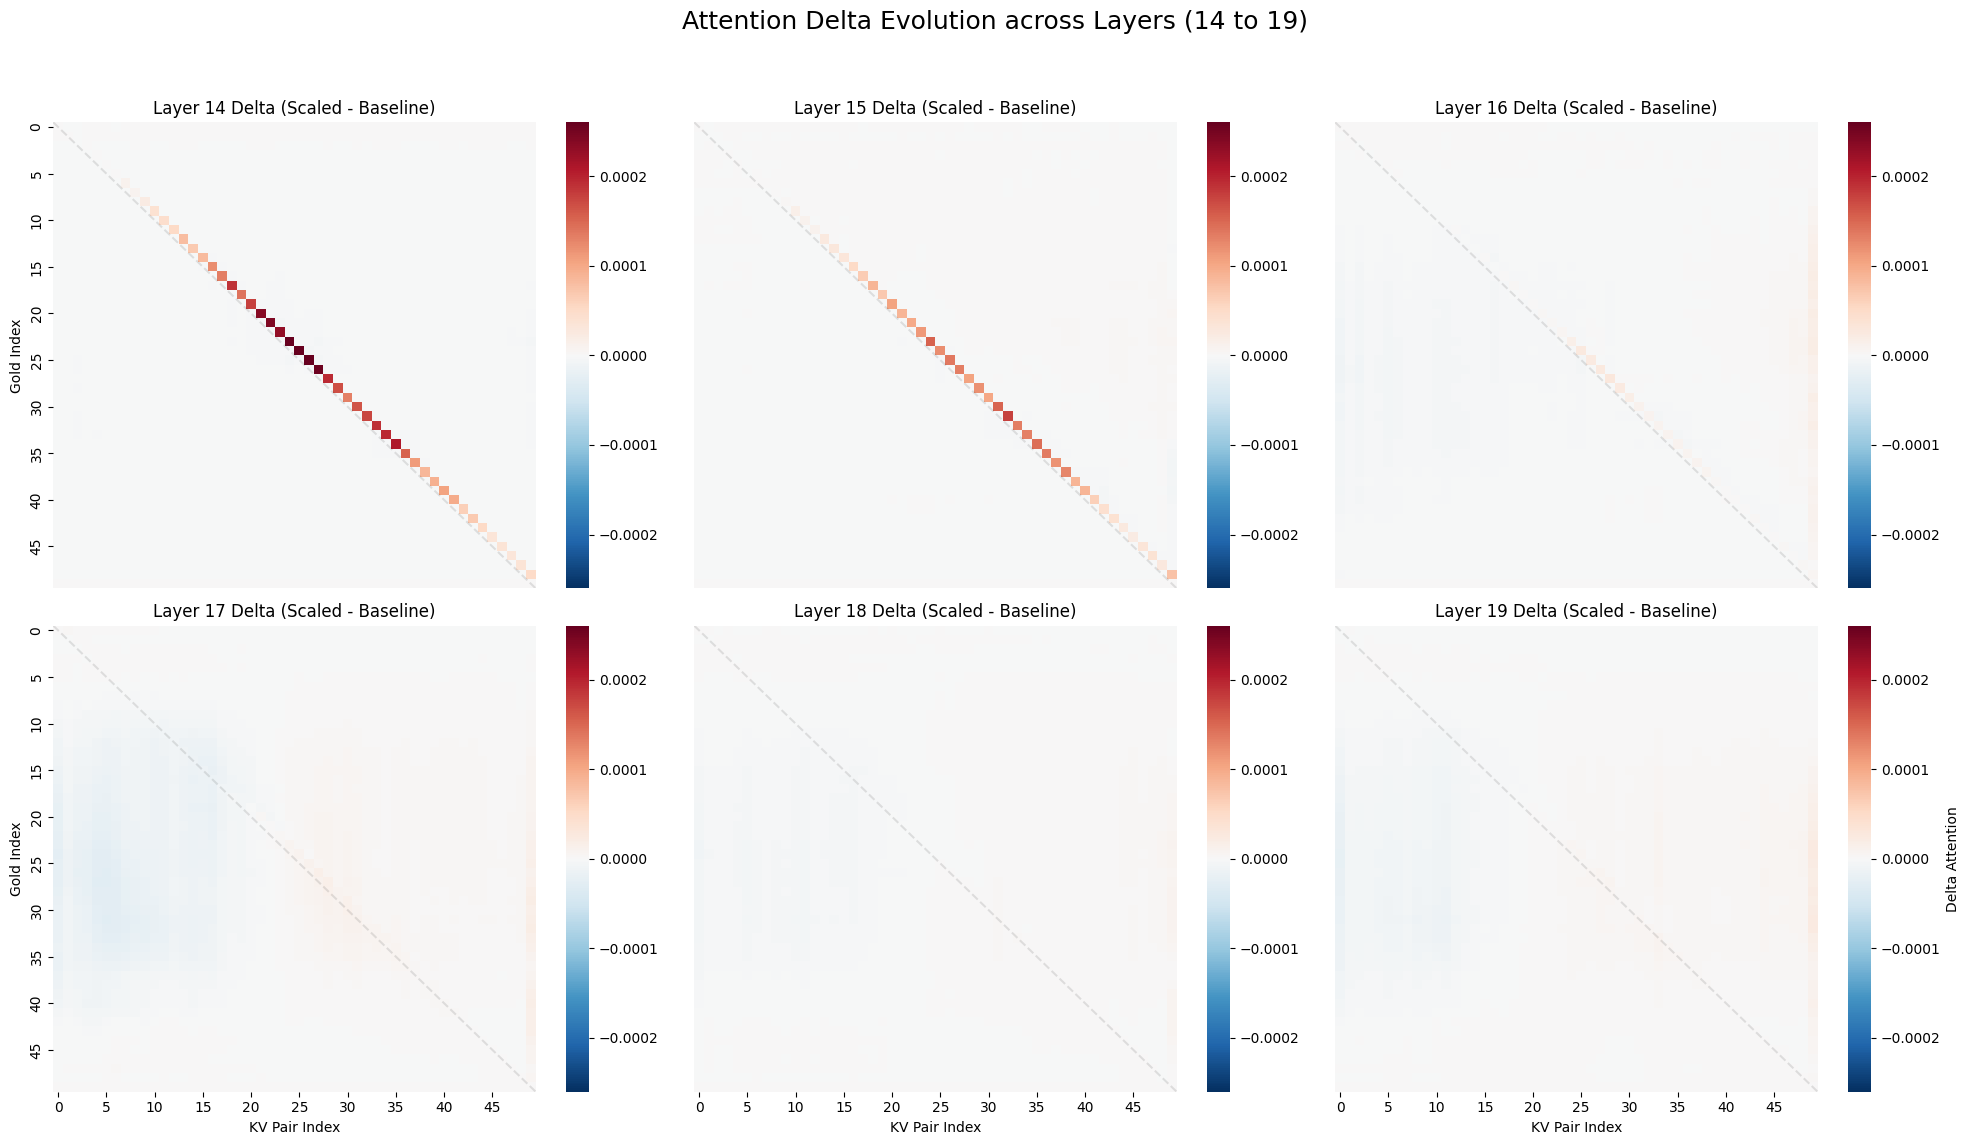

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

class KVLayerWiseDeltaAnalyst:
    def __init__(self, scaled_path, baseline_path):
        self.target_layers = [14, 15, 16, 17, 18, 19]
        # レイヤーごとの平均行列を辞書形式で取得 {layer: 50x50_matrix}
        self.scaled_layers = self._load_per_layer(scaled_path)
        self.baseline_layers = self._load_per_layer(baseline_path)

        # 差分を計算
        self.delta_layers = {
            l: self.scaled_layers[l] - self.baseline_layers[l]
            for l in self.target_layers
        }

    def _load_per_layer(self, file_path):
        """レイヤーごとに、全ヘッド平均をとった50x50行列を計算"""
        max_kv = 50
        # レイヤーごとに集計用バッファを作成
        accums = {l: np.zeros((max_kv + 1, max_kv)) for l in self.target_layers}
        counts = {l: np.zeros((max_kv + 1, max_kv)) for l in self.target_layers}

        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                rec = json.loads(line)
                gold_idx = rec.get("gold_index")
                if gold_idx is None or gold_idx > max_kv: continue

                kv_attns = rec["kv_pair_attentions"] # {layer_str: [[heads], ...]}

                for l_str, heads_data in kv_attns.items():
                    l_idx = int(l_str)
                    if l_idx not in self.target_layers: continue

                    # ヘッド次元で平均をとる (num_heads, 50) -> (50,)
                    avg_heads = np.mean(heads_data, axis=0)

                    num_pairs = min(len(avg_heads), max_kv)
                    accums[l_idx][gold_idx, :num_pairs] += avg_heads[:num_pairs]
                    counts[l_idx][gold_idx, :num_pairs] += 1

        # 各レイヤーについて平均化して1-50の範囲を返す
        result = {}
        for l in self.target_layers:
            final = np.divide(accums[l], counts[l], out=np.zeros_like(accums[l]), where=counts[l]!=0)
            result[l] = final[1:, :50]
        return result

    def plot_layer_delta_heatmaps(self):
        """全ターゲットレイヤーの差分マップを並べて表示"""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes = axes.flatten()

        # 全レイヤー共通のスケールを計算（比較しやすくするため）
        all_deltas = np.array(list(self.delta_layers.values()))
        v_limit = np.max(np.abs(all_deltas)) * 0.8

        for i, l_idx in enumerate(self.target_layers):
            ax = axes[i]
            sns.heatmap(
                self.delta_layers[l_idx],
                ax=ax,
                cmap="RdBu_r",
                center=0,
                vmin=-v_limit, vmax=v_limit,
                xticklabels=5 if i >= 3 else False, # 下段のみラベル表示
                yticklabels=5 if i % 3 == 0 else False, # 左端のみラベル表示
                cbar_kws={'label': 'Delta Attention'} if i == 5 else None
            )
            ax.set_title(f"Layer {l_idx} Delta (Scaled - Baseline)")
            if i >= 3: ax.set_xlabel("KV Pair Index")
            if i % 3 == 0: ax.set_ylabel("Gold Index")

            # 対角線
            ax.plot([0, 50], [0, 50], color='black', linestyle='--', alpha=0.1)

        plt.suptitle("Attention Delta Evolution across Layers (14 to 19)", fontsize=18)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# --- 実行コード ---
baseline_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_no_scale.jsonl"
scaled_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/kv_retrieval/attnmap_kv_retrieval_20_scale.jsonl"

analyst = KVLayerWiseDeltaAnalyst(scaled_path, baseline_path)
analyst.plot_layer_delta_heatmaps()

In [ ]:
# 終了用コード
from google.colab import runtime

runtime.unassign()